In [ ]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import cv2

from noise import add_gaussian_noise, add_salt_pepper_noise
from filters import gaussian_filter, median_filter
from metrics import psnr, ssim

print("Import thành công!")

Import thành công!


Ảnh gốc: (4016, 6016), dtype: uint8


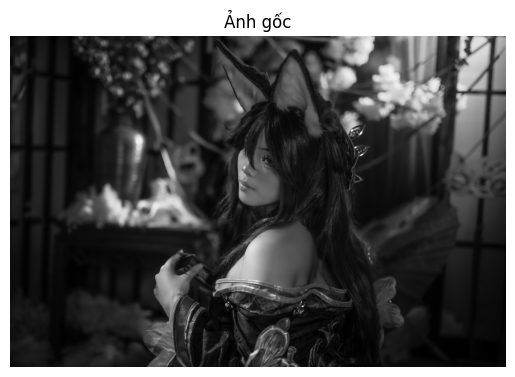

In [8]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

img_path = Path(r"W:\Denoise Project\classic_image_denoising_benchmark\Data\Gray test\HDH_0220.png")

img_color = cv2.imread(str(img_path))

if img_color is None:
    print("Không đọc được ảnh. Kiểm tra lại đường dẫn hoặc tên file.")
else:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    print(f"Ảnh gốc: {img_gray.shape}, dtype: {img_gray.dtype}")

    plt.imshow(img_gray, cmap="gray")
    plt.title("Ảnh gốc")
    plt.axis("off")
    plt.show()

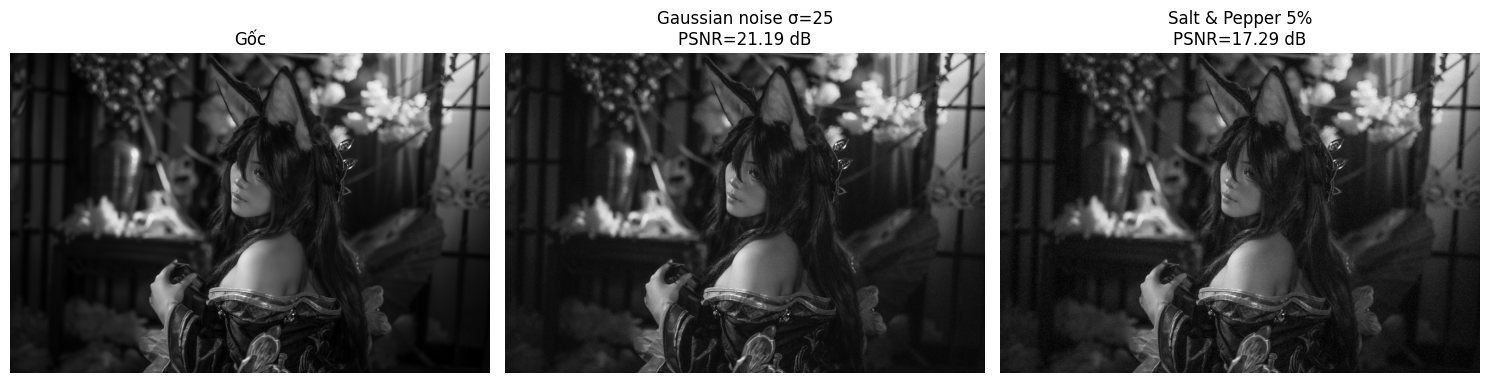

In [ ]:
sigma = 25  # Thử nghiệm với 25, 50, 75

noisy_gaussian = add_gaussian_noise(img_gray, sigma=sigma)
noisy_sp       = add_salt_pepper_noise(img_gray, prob=0.05)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Gốc")
axes[1].imshow(noisy_gaussian, cmap='gray')
axes[1].set_title(f"Gaussian noise σ={sigma}\nPSNR={psnr(img_gray, noisy_gaussian):.2f} dB")
axes[2].imshow(noisy_sp, cmap='gray')
axes[2].set_title(f"Salt & Pepper 5%\nPSNR={psnr(img_gray, noisy_sp):.2f} dB")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

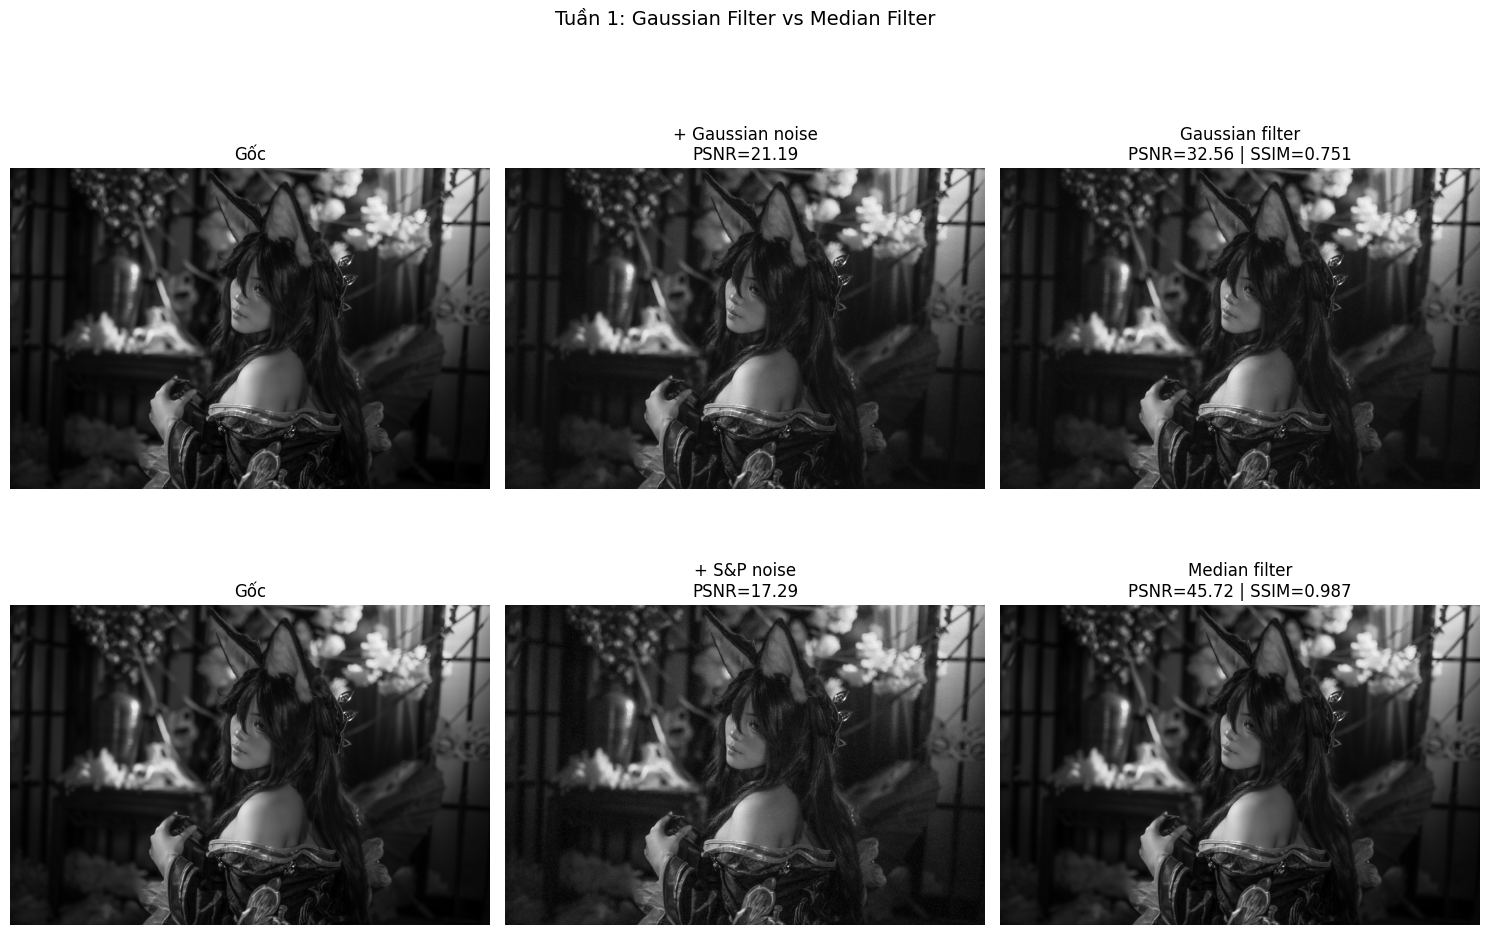

In [ ]:
denoised_gaussian = gaussian_filter(noisy_gaussian, kernel_size=5, sigma=1.5)
denoised_median   = median_filter(noisy_sp, kernel_size=3)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Gaussian noise
axes[0,0].imshow(img_gray, cmap='gray');        axes[0,0].set_title("Gốc")
axes[0,1].imshow(noisy_gaussian, cmap='gray');  axes[0,1].set_title(f"+ Gaussian noise\nPSNR={psnr(img_gray, noisy_gaussian):.2f}")
axes[0,2].imshow(denoised_gaussian, cmap='gray')
axes[0,2].set_title(f"Gaussian filter\nPSNR={psnr(img_gray, denoised_gaussian):.2f} | SSIM={ssim(img_gray, denoised_gaussian):.3f}")

# Salt & Pepper noise
axes[1,0].imshow(img_gray, cmap='gray');        axes[1,0].set_title("Gốc")
axes[1,1].imshow(noisy_sp, cmap='gray');        axes[1,1].set_title(f"+ S&P noise\nPSNR={psnr(img_gray, noisy_sp):.2f}")
axes[1,2].imshow(denoised_median, cmap='gray')
axes[1,2].set_title(f"Median filter\nPSNR={psnr(img_gray, denoised_median):.2f} | SSIM={ssim(img_gray, denoised_median):.3f}")

for ax in axes.flat: ax.axis('off')
plt.suptitle("Gaussian Filter vs Median Filter", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/test_25.png', dpi=150, bbox_inches='tight')
plt.show()